In [1]:
from bids import BIDSLayout
import numpy as np
from matplotlib import pyplot as plt
import mne

In [2]:
layout = BIDSLayout('erps', validate = False)

ValueError: BIDS root does not exist: /project/hcn1/Letty/pitch_tracking_attention/analysis/erps

In [59]:
evokeds = []
target_evs = []
nontarget_evs = []
for f in layout.get():
    try:
        epochs = mne.read_epochs(f.path)
    except:
        continue
    epochs = epochs.crop(-.1, None).apply_baseline() # baseline from -100ms for prettiness
    evo = epochs.average()
    evokeds.append(evo) # save average of all trials
    target_ids = ['11', '22', '33']
    target = epochs[target_ids].average()
    target_evs.append(target) # average of target trials
    nontarget_ids = [evid for evid in epochs.event_id if not evid in  target_ids]
    nontarget = epochs[nontarget_ids].average() # average of nontarget trials
    nontarget_evs.append(nontarget)

Reading /home/johnv/repos/letty/erps/sub-3/sub-3_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compensation matrices available
0 bad epochs dropped
Not setting metadata
4172 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Reading /home/johnv/repos/letty/erps/sub-4/sub-4_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compensation matrices available
0 bad epochs dropped
Not setting metadata
1332 matching events found
No baseline correction applied
0 projection items activated
Applying baseline correction (mode: mean)
Reading /home/johnv/repos/letty/erps/sub-5/sub-5_task-pitch_run-1_desc-forERPall_epo.fif.gz ...
    Found the data of interest:
        t =    -200.00 ...     499.00 ms
        0 CTF compensation matrices available
0 bad epochs 

Identifying common channels ...
No projector specified for this dataset. Please consider the method self.add_proj.


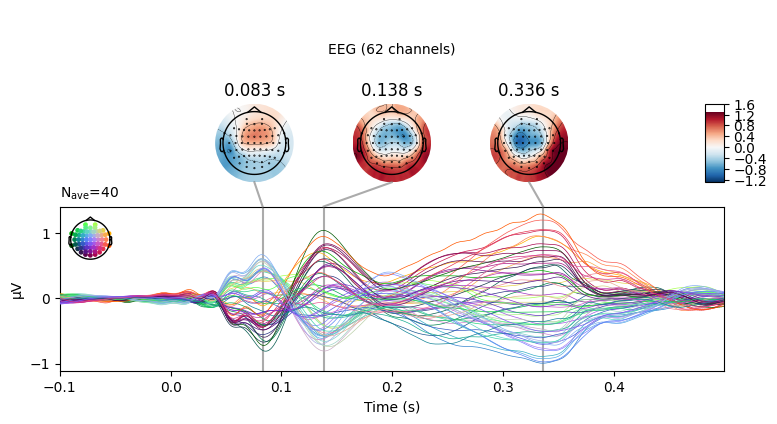

In [256]:
# plot grand average
from eeg_positions import get_elec_coords
evo = mne.grand_average(evokeds)
coords = get_elec_coords(as_mne_montage = True)
evo = evo.set_montage(coords)
evo.plot_joint()
plt.show()

In [259]:
# format data for paired sample target vs. non-target test
target_evs[0].get_data().shape
X = np.stack([t.get_data() for t in target_evs]) - np.stack([nt.get_data() for nt in nontarget_evs])
X.shape

(40, 62, 600)

In [265]:
# one-sample permutation t-test with t-max corrected p-values
_X = X.reshape((X.shape[0], X.shape[1] * X.shape[2]))
t, p, h0 = mne.stats.permutation_t_test(_X, n_jobs = -1)
t = t.reshape(X[0].shape)
p = p.reshape(X[0].shape)
print('p-value for whole ERP is', p.min())

Permuting 9999 times...


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    3.0s remaining:    3.0s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    3.1s finished


p-value for whole ERP is 0.0001


No projector specified for this dataset. Please consider the method self.add_proj.


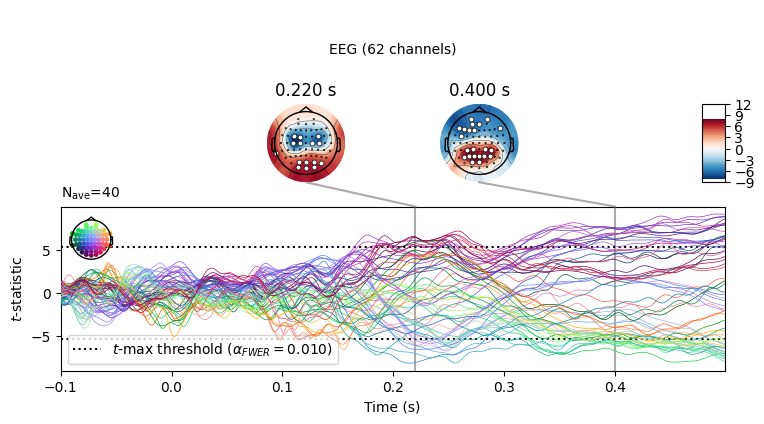

In [266]:
# plot results

alpha = .01

diff = evo.copy() # make a copy of evoked object and replace data
diff.data = t * 1e-6 # because MNE assumes microvolts in plots
fig = diff.plot_joint(
    times = [.22, .4], # you can put these wherever you like 
    topomap_args = dict(
        mask = p < alpha,
        mask_params = dict(markersize = 7)
    ),
    show = False
)
axs = fig.get_axes()
axs[0].set_ylabel(r'$t$-statistic')
axs[0].axhline(
    np.quantile(h0, 1 - alpha), 
    color = 'black', linestyle = 'dotted', 
    label = r'$t$-max threshold ($\alpha_{FWER} = %.03f$)'%alpha
)
axs[0].axhline(-np.quantile(h0, 1 - alpha), color = 'black', linestyle = 'dotted')
axs[0].legend(loc = 'lower left')
plt.show()

I don't have access to the participants' accuracy labels, but the following function should do the t-test for the between-subjects analysis, which can then be plotted similarly. 

In [267]:
from mne.parallel import parallel_func
from mne.stats.parametric import ttest_ind_no_p

def _get_t_max(X0, X1, seed):
    '''
    helper funciton for permutation test
    '''
    rng = np.random.default_rng(seed)
    x = np.concatenate([X0.copy(), X1.copy()])
    if seed != 0: # first permutation is always observed
        rng.shuffle(x, axis = 0) # permute
    x0, x1 = x[:X0.shape[0]], x[X0.shape[0]:]
    t = ttest_ind_no_p(x0, x1, equal_var = False)
    return np.abs(t).max()
    

def permutation_t_test_indep(X0, X1, n_perms = 9999):
    '''
    MNE doesn't provide a function for independent samples t-max procedure, 
    so here is one that does a two-tailed test for H0: X0 - X1 = 0

    Parameters
    ------------
    X0 : np.array of shape (n_subs0, a, b)
        first group
    X1 : np.array of shape (n_subs1, a, b)
        second group
    n_perms : int

    Returns
    ----------
    t : np.array of shape (a, b)
        t-value should be positive where X0 > X1
    p : np.array of shape (a, b)
    H0 : np.array of shape (n_perms,)
    '''
    parallel, p_func, n_jobs = parallel_func(
            _get_t_max, n_jobs = -1,
            verbose = 1
        )
    N_PERMUTATIONS = 100
    out = parallel(
            p_func(X0, X1, seed = i)
            for i in range(n_perms + 1)
        )
    h0 = np.array(out) # null distribution 
    t = ttest_ind_no_p(X0, X1, equal_var = False) # observed
    p = np.vectorize(lambda _t: (h0 >= _t).mean())(np.abs(t))
    print('p-value for whole ERP is', p.min())
    return t, p, h0